In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
episode_df = pd.read_csv(r"dataset\notFineTuned\episodes\episode_unbalanced.csv",index_col=0)
embeddings = np.load(r"dataset\notFineTuned\embeddings\unbalanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [62]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 122


,orig_index,content_id,sentence,published_date,category,episode
0,5111,1282697,"In addition to footage of customers, the devic...",2024-02-13,Gadgets,36
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,36
2,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,36
3,5067,1284526,"According to court documents, Vargas-Fernandez...",2024-02-15,Gadgets,36
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,36


In [63]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [64]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-13 00:00:00
End: 2024-12-03 00:00:00
Duration (days): 294


## Event Timeline

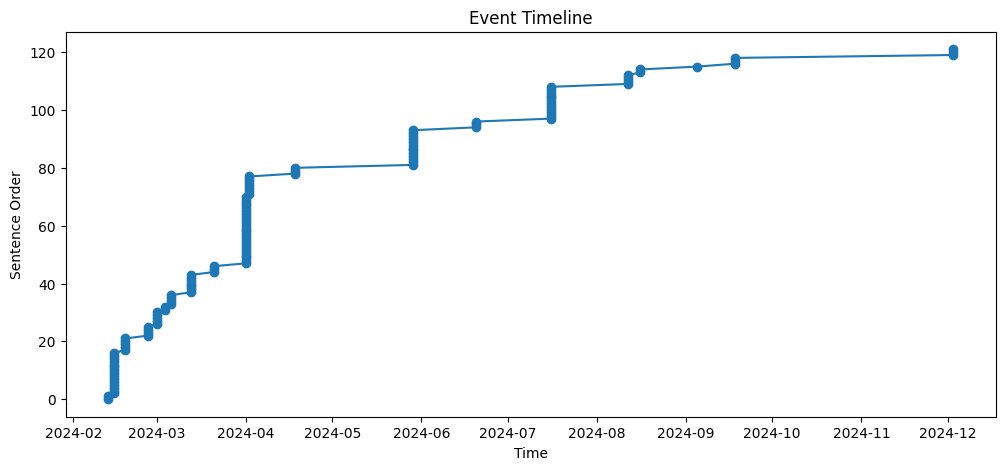

In [65]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

## Event Clustering

In [66]:
import hdbscan

In [67]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    metric='euclidean'
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [68]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,5111,1282697,"In addition to footage of customers, the devic...",2024-02-13,Gadgets,36,-1
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,36,-1
2,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,36,-1
3,5067,1284526,"According to court documents, Vargas-Fernandez...",2024-02-15,Gadgets,36,-1
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,36,-1


In [69]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 5
-1    79
 4    24
 1     5
 3     5
 0     5
 2     4
Name: event_id, dtype: int64


In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

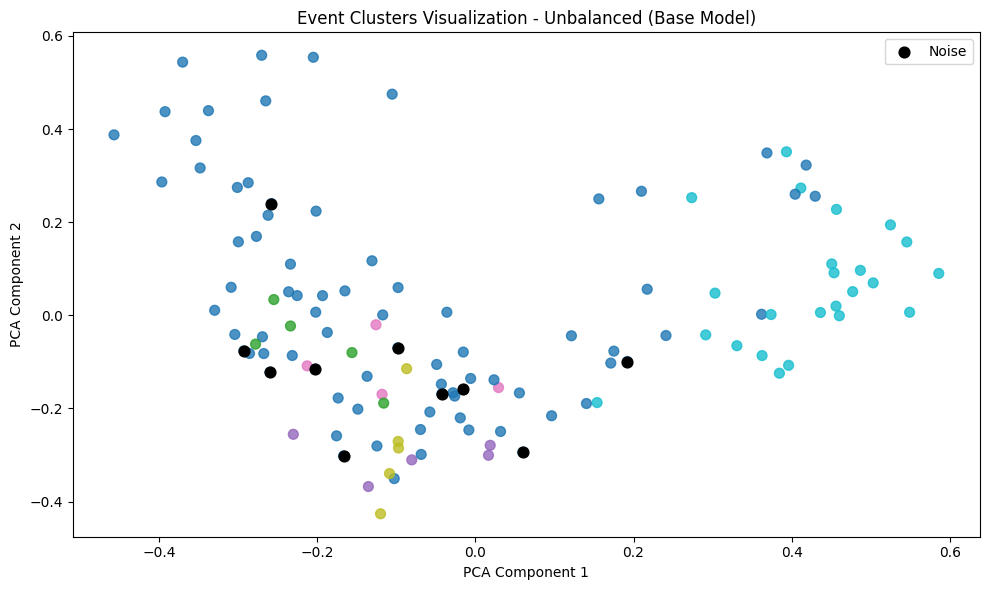

In [71]:
plt.style.use('default')
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
    cmap="tab10",
    s=50,
    alpha=0.8,
)

noise_idx = np.where(event_labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(10, len(noise_idx)), replace=False)

plt.scatter(
    reduced_embeddings[noise_sample,0],
    reduced_embeddings[noise_sample,1],
    color="black",
    s=60,
    label="Noise"
)

plt.title("Event Clusters Visualization - Unbalanced (Base Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend()

plt.tight_layout()
plt.show()

## Event Labelling

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
def generate_event_tag(sentence):

    vectorizer = TfidfVectorizer(stop_words='english', max_features=8)
    
    X = vectorizer.fit_transform([sentence])
    
    keywords = vectorizer.get_feature_names_out()

    tag = " ".join(keywords)

    return tag

In [74]:
from sklearn.metrics.pairwise import cosine_similarity

In [75]:
import textwrap


episode_df["event_tag"] = ""

for event in episode_df["event_id"].unique():

    if event == -1:
        continue

    cluster = episode_df[episode_df["event_id"] == event]

    cluster_embeddings = episode_embeddings[cluster.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    central_index = similarities.argmax()

    rep_sentence = cluster.iloc[central_index]["sentence"]
    
    wrapped = textwrap.fill(rep_sentence, width=100)
    
    print(f"\n==========Event {event}==========")
    print(f'"{wrapped}"\n')
    print("Similarity:", similarities.max())
    print(f"===========================")

    tag = generate_event_tag(rep_sentence)

    episode_df.loc[episode_df["event_id"] == event, "event_tag"] = tag


==========Event 1==========
"Police said Vargas-Fernandez removed the cameras after his fellow employee discovered them."

Similarity: 0.8838018010043087

==========Event 2==========
"After he left the first restroom, he came across two colleagues and told them he thought there was a
camera in the bathroom, and that “it was under the sink and it probably captured everyone with their
pants down”, according to court records."

Similarity: 0.8759399661636238

==========Event 3==========
"It was a hidden camera, which had several files on it, police said."

Similarity: 0.852131370454686

==========Event 4==========
"When it comes to privacy laws, homeowners and managers who rent through Airbnb and other platforms
rely on cameras when they’re not around."

Similarity: 0.9068106774059537

==========Event 0==========
"On the hidden camera, investigators found footage of Selleny committing a sexual act in the woman’s
home, and entering the apartment while she wasn’t there."

Similarity: 0.898

In [76]:
event_tag_map = (
    episode_df
    .drop_duplicates(subset=["event_id"])
    .sort_values("event_id")[["event_id", "event_tag"]]
)

print(event_tag_map)

    event_id                                          event_tag
0         -1                                                   
72         0  act apartment camera committing entering foota...
6          1  cameras discovered employee fellow fernandez p...
12         2  according bathroom came camera captured collea...
45         3                    camera files hidden police said
47         4  airbnb cameras comes homeowners laws managers ...


In [77]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    min_date = episode_df[episode_df["event_id"] == event]["published_date"].min().strftime("%d-%m-%Y")
    max_date = episode_df[episode_df["event_id"] == event]["published_date"].max().strftime("%d-%m-%Y")
    
    print("\n========================================================================================")
    print("Event ID:", event, "  {", list(event_tag_map.event_tag)[event+1],"}")
    print(f"Timeline: {min_date if min_date == max_date else f'{min_date} to {max_date}'}")
    print("========================================================================================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(3)
    episode_df[episode_df["event_id"] == event].to_csv(fr"dataset\notFineTuned\events\unbalanced\eventID-{event}.csv",index=False)

    # for s in event_sentences:
    #     wrapped = textwrap.fill(s,width=100)
    #     print("-", wrapped)


Event ID: 0   { act apartment camera committing entering footage hidden home }
Timeline: 02-04-2024 to 03-12-2024

Event ID: 1   { cameras discovered employee fellow fernandez police removed said }
Timeline: 15-02-2024

Event ID: 2   { according bathroom came camera captured colleagues court left }
Timeline: 15-02-2024 to 21-03-2024

Event ID: 3   { camera files hidden police said }
Timeline: 21-03-2024 to 12-08-2024

Event ID: 4   { airbnb cameras comes homeowners laws managers platforms privacy }
Timeline: 01-04-2024 to 29-05-2024


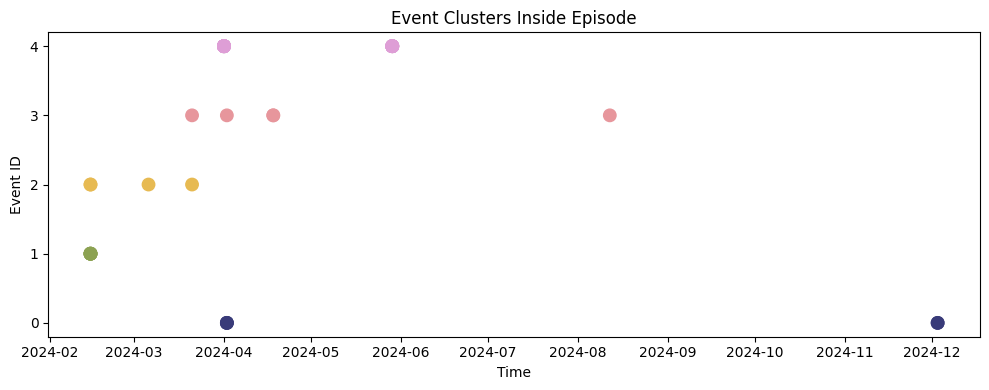

In [78]:
plt.figure(figsize=(10,4))

df_plot = episode_df[episode_df['event_id'] != -1]

plt.scatter(
    df_plot["published_date"],
    df_plot["event_id"],
    c=df_plot["event_id"],
    cmap="tab20b",
    s=80,
    alpha=1
)

plt.yticks(sorted(df_plot["event_id"].unique()))

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.tight_layout()
plt.show()